In [54]:
import numpy as np
from cvxopt import matrix, solvers
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs

X, y = make_blobs(n_samples=40, centers=[[2, 2], [-2, -2]], cluster_std=1.0, random_state=42)
y = np.where(y == 0, -1, 1).reshape(-1, 1)

C_pos = 20.0
C_neg = 5.0

In [55]:
n_samples, n_features = X.shape

C = np.where(y == 1, C_pos, C_neg)

P = matrix(np.dot(y * X, (y * X).T))
q = matrix(-C.astype(np.float64))
G = matrix(-np.eye(n_samples))
h = matrix(np.zeros(n_samples))
A = matrix(y.T.astype(np.float64))
b_cvx = matrix(0.0)

solvers.options['show_progress'] = False
solution = solvers.qp(P, q, G, h, A, b_cvx)

alphas = np.array(solution['x'])

In [56]:
w = np.sum(alphas * y * X, axis=0)

sv_idx = np.where(alphas > 1e-5)[0]

b_vals = y[sv_idx] * C[sv_idx] - np.dot(X[sv_idx], w.reshape(-1, 1))
b = np.mean(b_vals)

print("w:", w)
print("b:", b)

w: [-7.21933985 -6.93802679]
b: 6.960797894778092


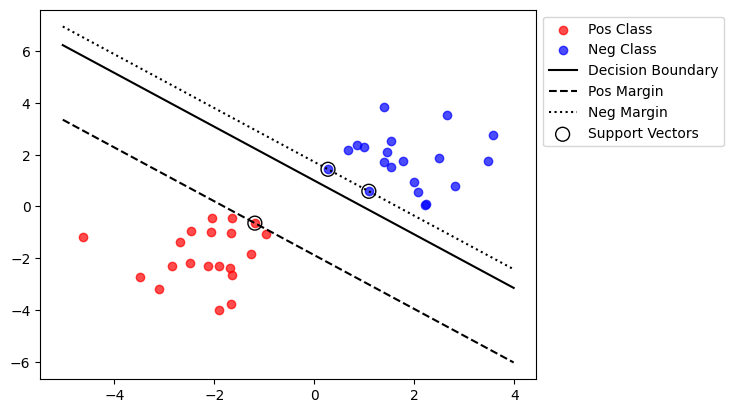

In [57]:
plt.scatter(X[y.flatten()==1, 0], X[y.flatten()==1, 1], c='red', alpha=0.7, label='Pos Class')
plt.scatter(X[y.flatten()==-1, 0], X[y.flatten()==-1, 1], c='blue', alpha=0.7, label='Neg Class')

ax = plt.gca()
xlim = ax.get_xlim()
xx = np.linspace(xlim[0], xlim[1], 50)

yy = (-w[0] * xx - b) / w[1]
yy_pos = (-w[0] * xx - b + C_pos) / w[1]
yy_neg = (-w[0] * xx - b - C_neg) / w[1]

plt.plot(xx, yy, 'k-', label='Decision Boundary')
plt.plot(xx, yy_pos, 'k--', label='Pos Margin')
plt.plot(xx, yy_neg, 'k:', label='Neg Margin')

plt.scatter(X[sv_idx, 0], X[sv_idx, 1], s=100, facecolors='none', edgecolors='k', label='Support Vectors')

plt.legend(loc='upper left', bbox_to_anchor=(1, 1))
plt.show()